In [23]:
import pandas as pd

try:
    df = pd.read_csv("Average-prices-Property-Type-2026-06.csv",index_col="Date")
    
    print(df)

except FileNotFoundError:
    print("Error: The file 'data.xlsx' was not found.")
except ValueError as e:
    print(f"ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

                          Region_Name  Area_Code  Detached_Average_Price  \
Date                                                                       
1995-01-01                    England  E92000001                 86969.0   
1995-01-01                      Wales  W92000004                 66840.0   
1995-01-01               Inner London  E13000001                239573.0   
1995-01-01               Outer London  E13000002                172477.0   
1995-01-01                     London  E12000007                176754.0   
...                               ...        ...                     ...   
2026-06-01              Cheshire East  E06000049                493244.0   
2026-06-01  Cheshire West and Chester  E06000050                437424.0   
2026-06-01          England and Wales  K04000001                463547.0   
2026-06-01              Great Britain  K03000001                450048.0   
2026-06-01             United Kingdom  K02000001                444652.0   

           

In [24]:
england = df[df["Region_Name"] == "England"]["Detached_Average_Price"]
england


Date
1995-01-01     86969.0
1995-02-01     85521.0
1995-03-01     85235.0
1995-04-01     86353.0
1995-05-01     85960.0
                ...   
2026-02-01    474274.0
2026-03-01    472122.0
2026-04-01    472471.0
2026-05-01    475529.0
2026-06-01    474647.0
Name: Detached_Average_Price, Length: 378, dtype: float64

In [25]:
england.isna()


Date
1995-01-01    False
1995-02-01    False
1995-03-01    False
1995-04-01    False
1995-05-01    False
              ...  
2026-02-01    False
2026-03-01    False
2026-04-01    False
2026-05-01    False
2026-06-01    False
Name: Detached_Average_Price, Length: 378, dtype: bool

In [26]:
england.index = pd.to_datetime(england.index)
england.index

DatetimeIndex(['1995-01-01', '1995-02-01', '1995-03-01', '1995-04-01',
               '1995-05-01', '1995-06-01', '1995-07-01', '1995-08-01',
               '1995-09-01', '1995-10-01',
               ...
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
               '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01'],
              dtype='datetime64[ns]', name='Date', length=378, freq=None)

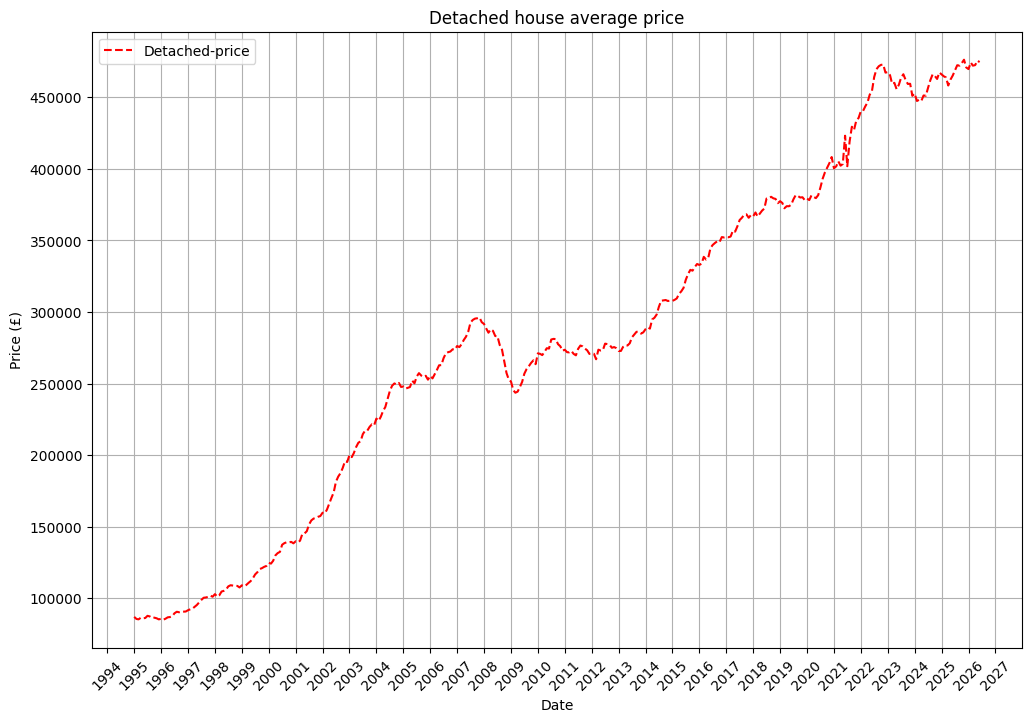

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,8))

plt.plot(england, color="red", linestyle="dashed", label="Detached-price")

plt.title("Detached house average price")
plt.xlabel("Date")
plt.ylabel("Price (£)")

# Show a tick every year
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.show()

In [28]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: {}'.format(result[0]))
    print('p-value: {}'.format(result[1]))
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t{}: {}'.format(key, value))

adf_test(england)

ADF Statistic: -0.4684779820238654
p-value: 0.8980224118620002
Critical Values:
	1%: -3.448645946352023
	5%: -2.869602139060357
	10%: -2.5710650077160495


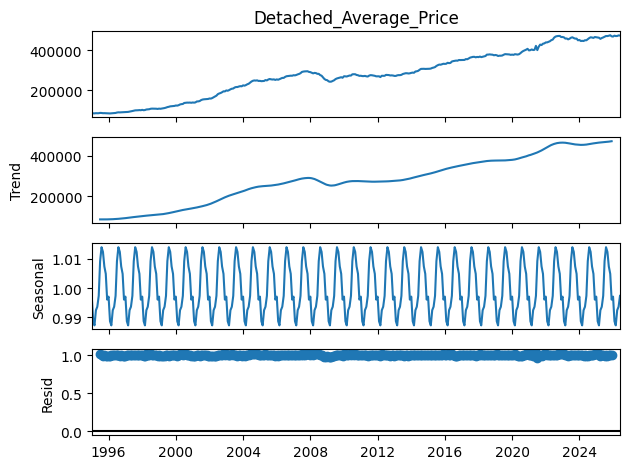

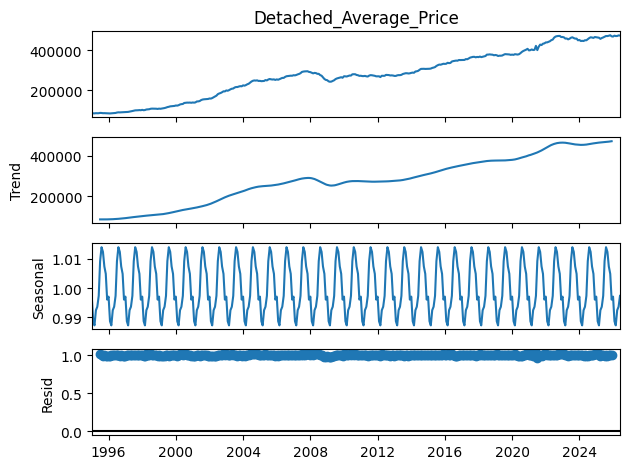

In [31]:
import statsmodels.api as sm
result = sm.tsa.seasonal_decompose(england, model='multiplicative', period=12)
trend = result.trend
seasonal = result.seasonal
residual = result.resid

result.plot()

In [32]:
england_diff = england.diff().dropna()
england_seasonal_diff = england_diff.diff(12).dropna()


def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: {}'.format(result[0]))
    print('p-value: {}'.format(result[1]))
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t{}: {}'.format(key, value))

adf_test(england_seasonal_diff)


ADF Statistic: -5.461304128112975
p-value: 2.515074874404801e-06
Critical Values:
	1%: -3.4491725955218655
	5%: -2.8698334971428574
	10%: -2.5711883591836733


<Figure size 1200x600 with 0 Axes>

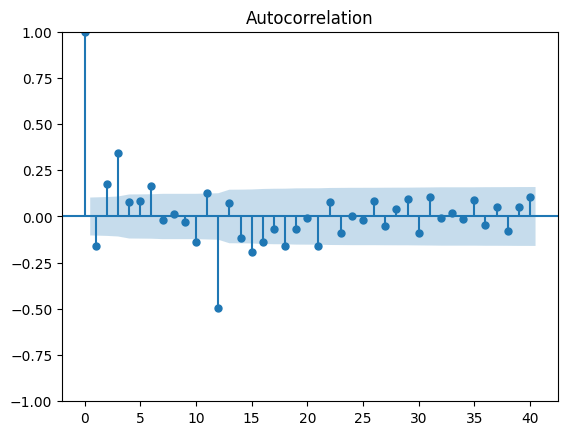

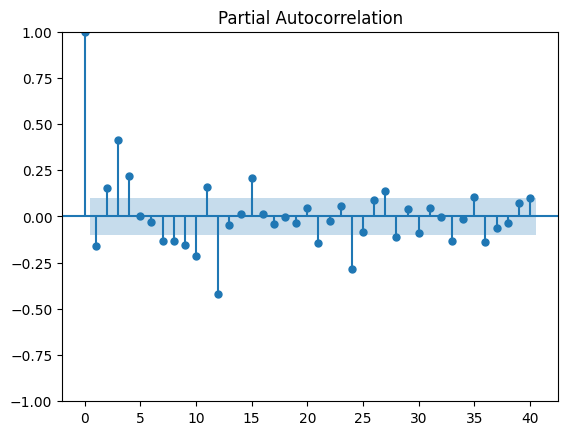

In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_acf(england_seasonal_diff.dropna(), lags=40)
plot_pacf(england_seasonal_diff.dropna(), lags=40)
plt.show()


In [16]:
import pmdarima as pm
train = england[:-12]
test = england[-12:]

model = pm.auto_arima(   #when you want Python to automatically choose the best ARIMA settings.
    train,
    seasonal=True,
    m=12,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=6928.750, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=6936.872, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=6936.649, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=6937.276, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=6970.776, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=6926.773, Time=0.46 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=6928.441, Time=0.18 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=6926.223, Time=0.87 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=6928.017, Time=2.00 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=6928.331, Time=0.56 sec
 ARIMA(2,1,1)(0,0,2)[12] intercept   : AIC=6931.978, Time=0.56 sec
 ARIMA(3,1,2)(0,0,2)[12] intercept   : AIC=6924.517, Time=0.91 sec
 ARIMA(3,1,2)(0,0,1)[12] intercept   : AIC=6926.317, Time=0.47 sec
 ARIMA(3,1,2)(1,0,2)[12] intercept   : AIC=6920.021, Time=1.43 sec
 ARIMA(3,1,2)(1,0,1

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  366
Model:             SARIMAX(3, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -3444.964
Date:                                 Sun, 23 Aug 2026   AIC                           6903.927
Time:                                         18:41:12   BIC                           6931.227
Sample:                                     01-01-1995   HQIC                          6914.776
                                          - 06-01-2025                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0399      0.018     -2.268      0.023      -0.074      -0.005
ar.L2          0.0890      0.014      6.225      0.000       0.061       0.117
ar.L3          0.1506      0.011     14.071      0.000       0.130       0.172
ar.S.L12       0.9421      0.030     31.113      0.000       0.883       1.001
ma.S.L12      -0.9170      0.042    -21.715      0.000      -1.000      -0.834
ma.S.L24       0.0305      0.029      1.057      0.291      -0.026       0.087
sigma2       9.14e+06   8.81e-10   1.04e+16      0.000    9.14e+06    9.14e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):              2498.15
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               3.54   Skew:                            -0.60
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.03e+32. Standard errors may be unstable.
"""

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(england, order=(3,1,0), seasonal_order=(1,0,2,12))
results = model.fit()


c:\Users\Invate\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Invate\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


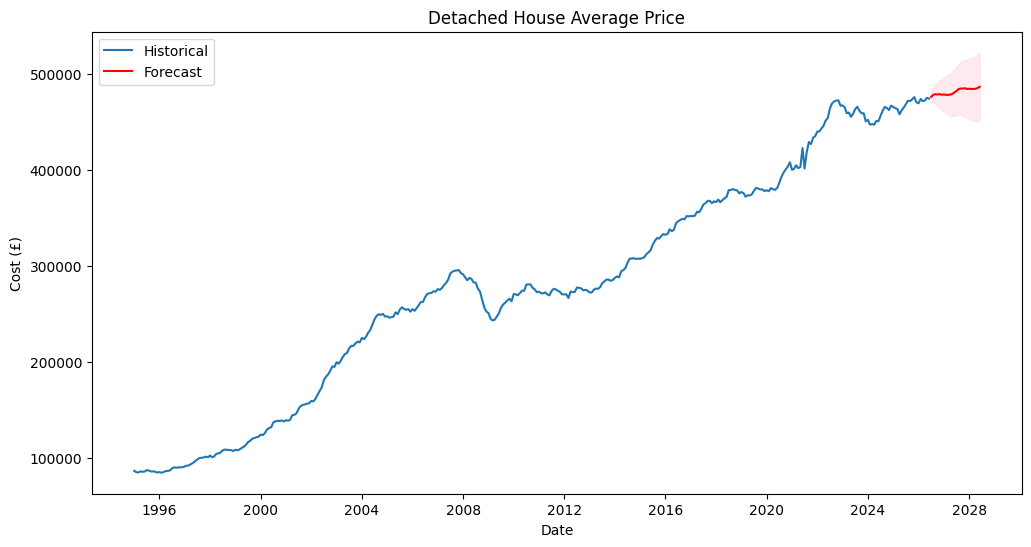

In [34]:
forecast_steps = 24
forecast = results.get_forecast(steps=forecast_steps)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()
future_index = pd.date_range(
    start=england.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)
mean_forecast.index = future_index
conf_int.index = future_index

plt.figure(figsize=(12,6))
plt.xlabel("Date")
plt.ylabel("Cost (£)")
# Historical
plt.plot(england.index, england, label='Historical')

# Forecast
plt.plot(mean_forecast.index, mean_forecast, label='Forecast', color='red')

# Confidence intervals
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color='pink',
    alpha=0.3
)

plt.title('Detached House Average Price')
plt.legend()
plt.show()


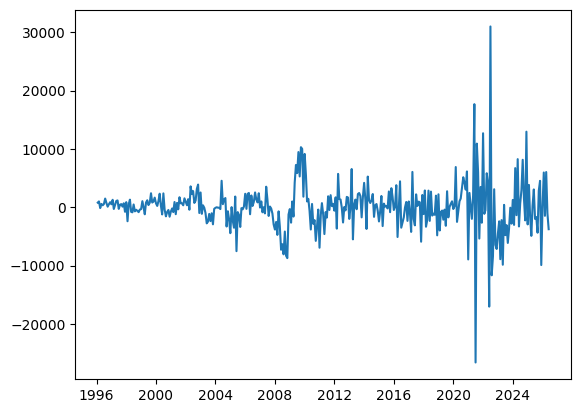

In [37]:
plt.plot(england_seasonal_diff)